In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('train.csv')

In [37]:
df.head()

,speed,trip_distance,passenger_count,pickup_hour_of_day,is_anomaly,pickup_day_of_week,traffic_congestion,trip_duration
0,11.856428,1.498521,1,17,0,0,0,455
1,9.803659,1.805507,1,0,0,6,0,663
2,10.822201,6.385098,1,11,0,1,1,2124
3,12.465721,1.485498,1,19,0,2,0,429
4,9.836594,1.188588,1,13,0,5,0,435


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458579 entries, 0 to 1458643
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   speed               1458579 non-null  float64
 1   trip_distance       1458579 non-null  float64
 2   passenger_count     1458579 non-null  int64  
 3   pickup_hour_of_day  1458579 non-null  int32  
 4   is_anomaly          1458579 non-null  int64  
 5   pickup_day_of_week  1458579 non-null  int32  
 6   traffic_congestion  1458579 non-null  int64  
 7   trip_duration       1458579 non-null  int64  
dtypes: float64(2), int32(2), int64(4)
memory usage: 89.0 MB


In [4]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [5]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In [6]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['pickup_date'] = df['pickup_datetime'].dt.date


In [7]:
daily_trips = df.groupby('pickup_date').size().reset_index(name='trip_count')


In [8]:
mean_trips = daily_trips['trip_count'].mean()
std_trips = daily_trips['trip_count'].std()
print(mean_trips)
print(std_trips)

8014.527472527472
925.7670893161951


In [9]:
c = 1.5
lower_bound = mean_trips - c* std_trips
upper_bound = mean_trips + c* std_trips


In [10]:
high_anomaly = daily_trips[daily_trips['trip_count'] > upper_bound]
low_anomaly = daily_trips[daily_trips['trip_count'] < lower_bound]
anomalous_days = pd.concat([high_anomaly, low_anomaly])


In [11]:
df['is_anomaly'] = 0
df.loc[df['pickup_date'].isin(anomalous_days['pickup_date']), 'is_anomaly'] = 1


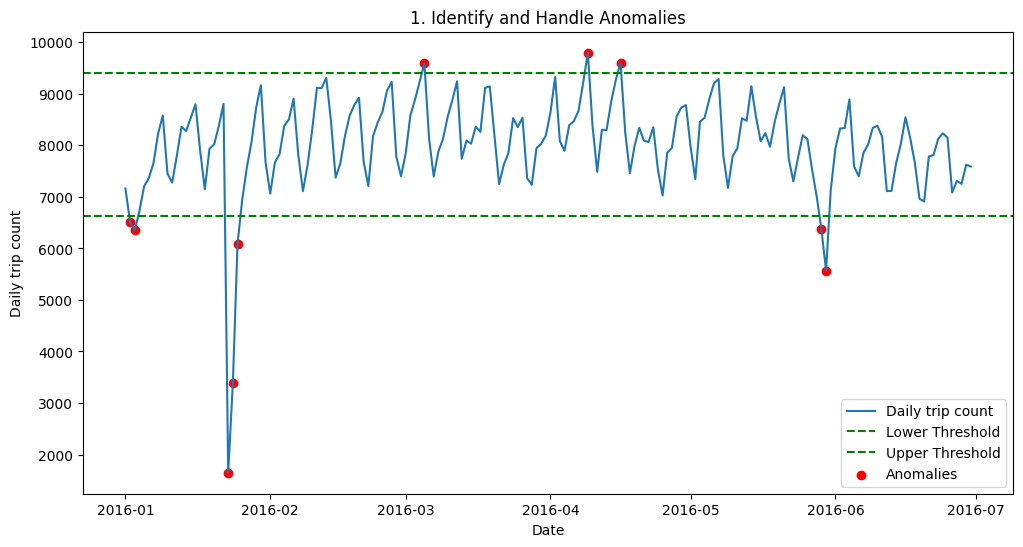

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(daily_trips['pickup_date'], daily_trips['trip_count'], label='Daily trip count')
plt.axhline(y=lower_bound, color='g', linestyle='--', label='Lower Threshold')
plt.axhline(y=upper_bound, color='g', linestyle='--', label='Upper Threshold')
plt.scatter(anomalous_days['pickup_date'], anomalous_days['trip_count'], color='red', label='Anomalies')
plt.title('1. Identify and Handle Anomalies')
plt.xlabel('Date')
plt.ylabel('Daily trip count')
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['vendor_id'] = le.fit_transform(df['vendor_id'])
df.head()

In [ ]:
df['vendor_id'].value_counts()

In [13]:
df['pickup_day_of_year'] = df['pickup_datetime'].dt.year
df['pickup_day_of_week'] = df['pickup_datetime'].dt.weekday  
df['pickup_hour_of_day'] = df['pickup_datetime'].dt.hour

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,is_anomaly,pickup_day_of_year,pickup_day_of_week,pickup_hour_of_day
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,0,2016,0,17
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,2016,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,0,2016,1,11
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,0,2016,2,19
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,0,2016,5,13


In [14]:
passenger_counts = df['passenger_count'].value_counts().sort_index()
print(passenger_counts)

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64


In [15]:
df = df[~df['passenger_count'].isin([0,7,8,9])]
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,is_anomaly,pickup_day_of_year,pickup_day_of_week,pickup_hour_of_day
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,0,2016,0,17
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,2016,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,0,2016,1,11
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,0,2016,2,19
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,0,2016,5,13


In [22]:
import math

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0 

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df = df.copy()

df['trip_distance'] = haversine_vectorized(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)


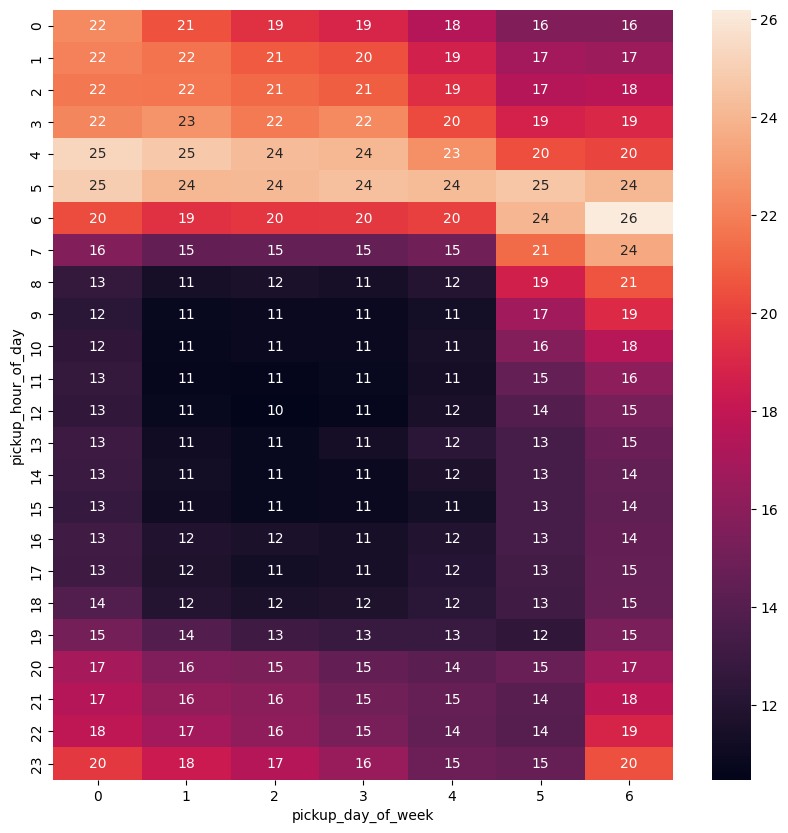

In [23]:
df['speed'] = df['trip_distance'] / (df['trip_duration'] / 3600)

df_avg = df.groupby(['pickup_day_of_week', 'pickup_hour_of_day'])['speed'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 10))
df_temp = df_avg.pivot(index='pickup_hour_of_day', columns='pickup_day_of_week', values='speed')
sns.heatmap(df_temp, annot=True, ax=ax)
plt.show()

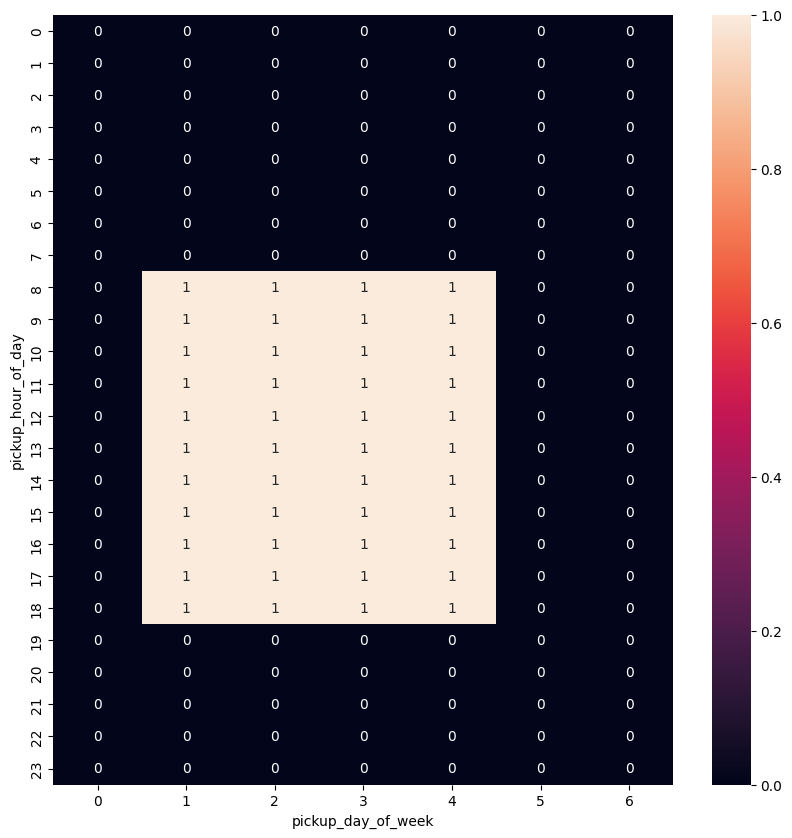

In [24]:
df_avg['traffic_congestion'] = 0
# Based on heatmap I choosed this: 
df_avg.loc[(((8 <= df_avg['pickup_hour_of_day']) & (df_avg['pickup_hour_of_day'] <= 18)) & ((1 <= df_avg['pickup_day_of_week']) & (df_avg['pickup_day_of_week'] <= 4))), 'traffic_congestion'] = 1
df_grb = df_avg.groupby(['pickup_day_of_week', 'pickup_hour_of_day'])[['traffic_congestion']].max().reset_index()
df_temp = df_grb.pivot(index='pickup_hour_of_day', columns='pickup_day_of_week', values='traffic_congestion')

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df_temp, annot=True, ax=ax)
plt.show()

In [25]:
# My trafic condition convert to train dataframe
df['traffic_congestion'] = 0
df.loc[(((8 <= df['pickup_hour_of_day']) & (df['pickup_hour_of_day'] <= 18)) & ((1 <= df['pickup_day_of_week']) & (df['pickup_day_of_week'] <= 4))), 'traffic_congestion'] = 1

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,is_anomaly,pickup_day_of_year,pickup_day_of_week,pickup_hour_of_day,trip_distance,speed,traffic_congestion
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,0,2016,0,17,1.498521,11.856428,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,2016,6,0,1.805507,9.803659,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,0,2016,1,11,6.385098,10.822201,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,0,2016,2,19,1.485498,12.465721,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,0,2016,5,13,1.188588,9.836594,0


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split

numerical_features = [
    'speed',
    'trip_distance',
    'passenger_count',
    'pickup_hour_of_day',
]

categorical_features = [
    'is_anomaly',
    'pickup_day_of_week',
    'traffic_congestion',
]

In [35]:
df = df[numerical_features+categorical_features+['trip_duration']]
train, test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

X_train = train.drop(columns=['trip_duration'])
y_train = train['trip_duration']
X_test = test.drop(columns=['trip_duration'])
y_test = test['trip_duration']

In [36]:
X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("RMSE:", rmse)
print("R² (train):", model.score(X_train, y_train))
print("R² (test):", model.score(X_test, y_test))

RMSE: 3117.37517363726
R² (train): 0.012140871265882036
R² (test): 0.04422471867817446
